# 1D CNN training for coin peak classification

This notebook trains a **1D CNN** on your UART peak CSV where:

- each row = **one detected peak**
- `label` = class name
- `s0 ... s2559` = signal samples

It will:

1. load and clean the CSV
2. split into train / validation / test
3. normalize each signal row
4. train a 1D CNN
5. save the best model
6. evaluate on the test set

> Assumed CSV columns: `timestamp`, `label`, `peak_index`, `s0...s2559`


In [142]:
# Run this only if you are missing packages
# %pip install numpy pandas matplotlib scikit-learn torch torchvision torchaudio


In [143]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [144]:
# -----------------------------
# CONFIG
# -----------------------------
CSV_PATH = "coin_dataset/all_peaks.csv"   # or all_peaks_8000.csv if you renamed it
MODEL_SAVE_PATH = "best_1dcnn.pth"
LABELS_SAVE_PATH = "class_names.json"

RANDOM_SEED = 42
BATCH_SIZE = 16      # safer first, because 8000-length inputs use more memory
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VAL_SIZE = 0.15
TEST_SIZE = 0.15

EXPECTED_SIGNAL_LEN = 8000

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [145]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


In [146]:
# -----------------------------
# LOAD CSV
# -----------------------------
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
display(df.head())


Shape: (254, 8003)


,timestamp,label,peak_index,s0,s1,s2,s3,s4,s5,s6,...,s7990,s7991,s7992,s7993,s7994,s7995,s7996,s7997,s7998,s7999
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21:13.9,D30_H10,101.0,1990.0,1991.0,1992.0,1989.0,1986.0,1986.0,1985.0,...,1989.0,1990.0,1995.0,1998.0,2000.0,2004.0,2007.0,2009.0,2007.0,2000.0
3,21:19.8,D30_H10,102.0,1993.0,1992.0,1993.0,1993.0,1995.0,1994.0,1995.0,...,1990.0,1989.0,1988.0,1988.0,1989.0,1988.0,1978.0,1986.0,1986.0,1988.0
4,21:25.2,D30_H10,103.0,1991.0,1985.0,1989.0,1990.0,1990.0,1986.0,1988.0,...,1997.0,1996.0,1993.0,1987.0,1985.0,1990.0,1995.0,2000.0,2002.0,1981.0


In [147]:
# -----------------------------
# FIND SIGNAL COLUMNS
# -----------------------------
signal_cols = [c for c in df.columns if c.startswith("s")]
signal_cols = sorted(signal_cols, key=lambda x: int(x[1:]))

if "label" not in df.columns:
    raise ValueError("CSV must contain a 'label' column.")

print("Number of signal columns found:", len(signal_cols))

if len(signal_cols) != EXPECTED_SIGNAL_LEN:
    print(f"Warning: expected {EXPECTED_SIGNAL_LEN} signal columns but found {len(signal_cols)}")

print("Number of signal columns found:", len(signal_cols))

if len(signal_cols) != EXPECTED_SIGNAL_LEN:
    print(f"Warning: expected {EXPECTED_SIGNAL_LEN} signal columns but found {len(signal_cols)}")


Number of signal columns found: 8000
Number of signal columns found: 8000


In [148]:
# -----------------------------
# CLEAN DATA
# -----------------------------
# Keep only label + signal columns for training
work_df = df[["label"] + signal_cols].copy()

# Convert signals to numeric
for c in signal_cols:
    work_df[c] = pd.to_numeric(work_df[c], errors="coerce")

# Drop rows with missing label or bad numeric values
before = len(work_df)
work_df = work_df.dropna().reset_index(drop=True)
after = len(work_df)

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning : {after}")
print("\nClass counts:")
print(work_df["label"].value_counts())


Rows before cleaning: 254
Rows after cleaning : 200

Class counts:
label
D30_H10    50
D30_H30    50
D10_H30    50
D10_H10    50
Name: count, dtype: int64


In [149]:
# -----------------------------
# EXTRACT X AND y
# -----------------------------
class_names = sorted(work_df["label"].unique().tolist())
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

X = work_df[signal_cols].values.astype(np.float32)
y = work_df["label"].map(class_to_idx).values.astype(np.int64)

print("Classes:", class_names)
print("X shape:", X.shape)
print("y shape:", y.shape)


Classes: ['D10_H10', 'D10_H30', 'D30_H10', 'D30_H30']
X shape: (200, 8000)
y shape: (200,)


In [150]:
# -----------------------------
# TRAIN / VAL / TEST SPLIT
# -----------------------------
# First split off the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

# Then split the remaining into train and val
val_ratio_of_temp = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio_of_temp,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (139, 8000) (139,)
Val  : (31, 8000) (31,)
Test : (30, 8000) (30,)


## Normalization choice

This notebook uses **per-row z-score normalization**:

\[
x' = \frac{x - \mu}{\sigma + \epsilon}
\]

That is usually a good starting point for waveform classification because each captured peak may have a slightly different baseline or amplitude scale.


In [151]:
def normalize_per_row(x):
    mean = x.mean(axis=1, keepdims=True)
    std = x.std(axis=1, keepdims=True)
    return (x - mean) / (std + 1e-8)

X_train = normalize_per_row(X_train)
X_val   = normalize_per_row(X_val)
X_test  = normalize_per_row(X_test)

print("Normalization done.")


Normalization done.


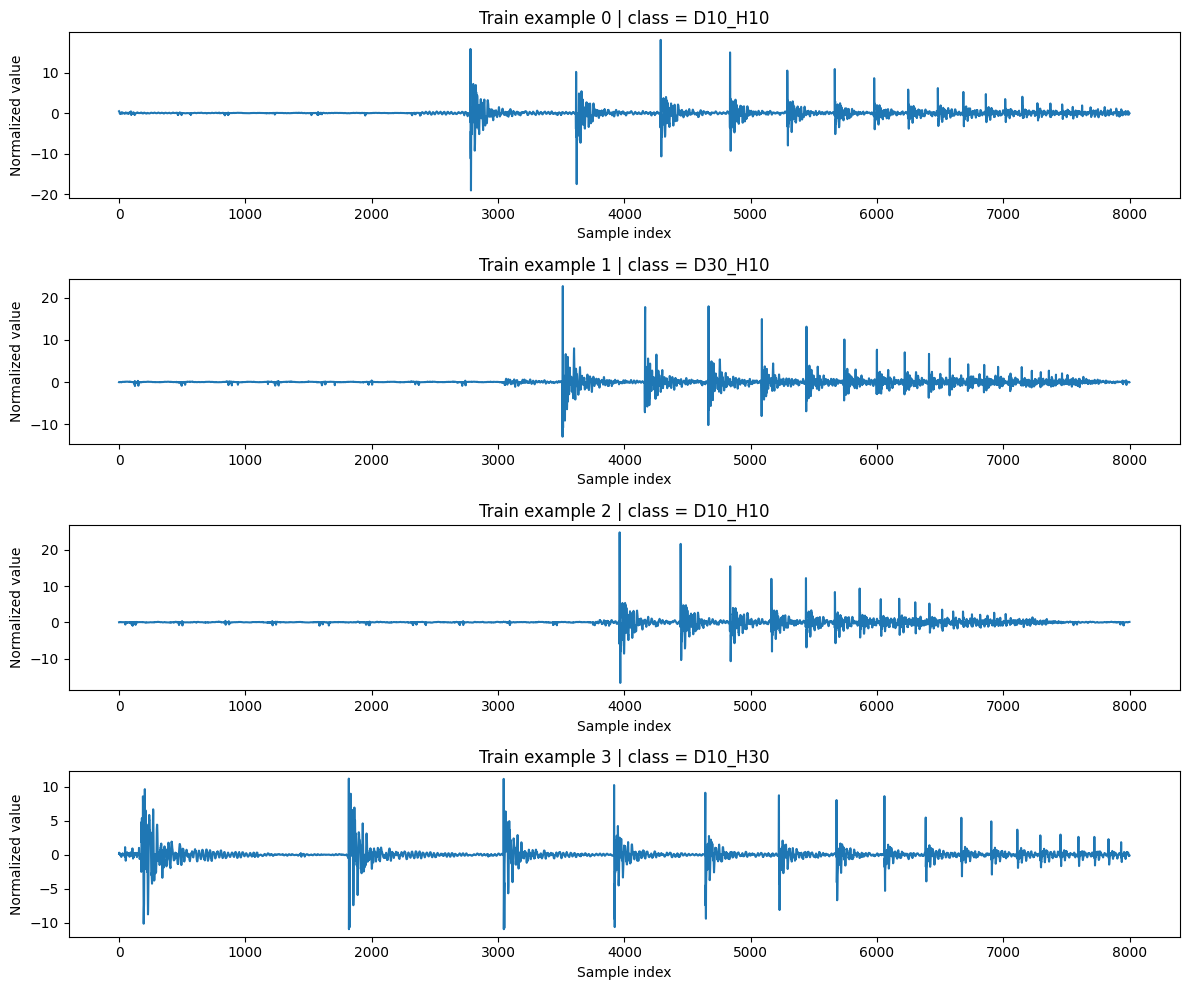

In [152]:
# -----------------------------
# QUICK VISUAL CHECK
# -----------------------------
num_to_show = min(4, len(X_train))
fig, axes = plt.subplots(num_to_show, 1, figsize=(12, 2.5 * num_to_show))
if num_to_show == 1:
    axes = [axes]

for i in range(num_to_show):
    axes[i].plot(X_train[i])
    axes[i].set_title(f"Train example {i} | class = {idx_to_class[int(y_train[i])]}")
    axes[i].set_xlabel("Sample index")
    axes[i].set_ylabel("Normalized value")

plt.tight_layout()
plt.show()


In [153]:
class PeakDataset(Dataset):
    def __init__(self, X, y):
        # Conv1D expects shape: [batch, channels, length]
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # [N, 1, 2560]
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = PeakDataset(X_train, y_train)
val_ds   = PeakDataset(X_val, y_val)
test_ds  = PeakDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Dataloaders ready.")


Dataloaders ready.


In [154]:
class Coin1DCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = Coin1DCNN(num_classes=len(class_names)).to(DEVICE)
print(model)


Coin1DCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15):

In [155]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


In [156]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        if training:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += xb.size(0)

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    return avg_loss, avg_acc


In [157]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        with open(LABELS_SAVE_PATH, "w", encoding="utf-8") as f:
            json.dump(class_names, f, indent=2)
        print(f"  Saved new best model to {MODEL_SAVE_PATH}")


Epoch 01/100 | train_loss=1.3701 train_acc=0.3813 | val_loss=1.3803 val_acc=0.2581
  Saved new best model to best_1dcnn.pth
Epoch 02/100 | train_loss=1.2637 train_acc=0.5252 | val_loss=1.3206 val_acc=0.2581
Epoch 03/100 | train_loss=1.1004 train_acc=0.6259 | val_loss=1.1619 val_acc=0.4839
  Saved new best model to best_1dcnn.pth
Epoch 04/100 | train_loss=0.9286 train_acc=0.6835 | val_loss=0.9080 val_acc=0.4839
Epoch 05/100 | train_loss=0.7400 train_acc=0.7266 | val_loss=0.7014 val_acc=0.9032
  Saved new best model to best_1dcnn.pth
Epoch 06/100 | train_loss=0.6262 train_acc=0.7050 | val_loss=0.5649 val_acc=0.7742
Epoch 07/100 | train_loss=0.5190 train_acc=0.7770 | val_loss=0.4328 val_acc=0.7419
Epoch 08/100 | train_loss=0.4545 train_acc=0.7914 | val_loss=0.4019 val_acc=0.7419
Epoch 09/100 | train_loss=0.4356 train_acc=0.7122 | val_loss=0.3669 val_acc=0.7419
Epoch 10/100 | train_loss=0.4231 train_acc=0.7338 | val_loss=0.3783 val_acc=0.7742
Epoch 11/100 | train_loss=0.3917 train_acc=0.79

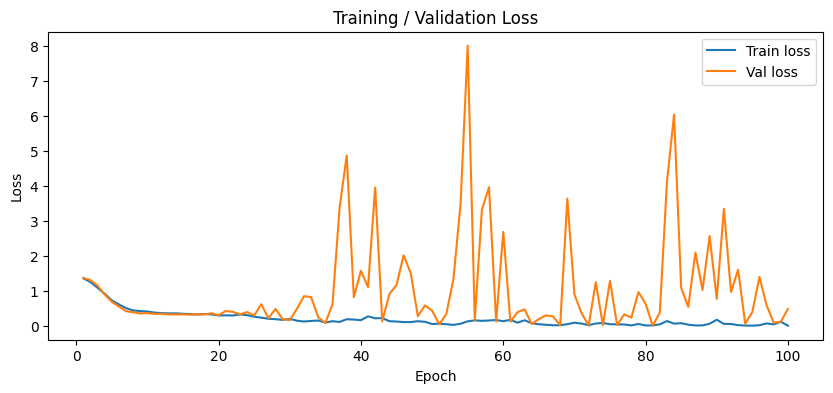

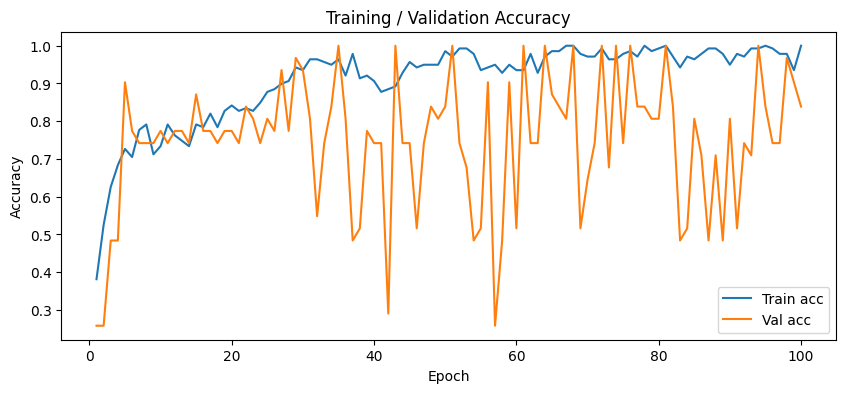

In [158]:
# -----------------------------
# PLOT TRAINING CURVES
# -----------------------------
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs, history["train_acc"], label="Train acc")
plt.plot(epochs, history["val_acc"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")
plt.legend()
plt.show()


In [159]:
# -----------------------------
# LOAD BEST MODEL AND TEST
# -----------------------------
best_model = Coin1DCNN(num_classes=len(class_names)).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
best_model.eval()

test_loss, test_acc = run_one_epoch(best_model, test_loader, criterion, optimizer=None)
print(f"Test loss: {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")


Test loss: 0.0991
Test acc : 1.0000


In [160]:
# -----------------------------
# DETAILED TEST REPORT
# -----------------------------
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_true.extend(yb.numpy().tolist())

print(classification_report(all_true, all_preds, target_names=class_names))


              precision    recall  f1-score   support

     D10_H10       1.00      1.00      1.00         8
     D10_H30       1.00      1.00      1.00         7
     D30_H10       1.00      1.00      1.00         8
     D30_H30       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



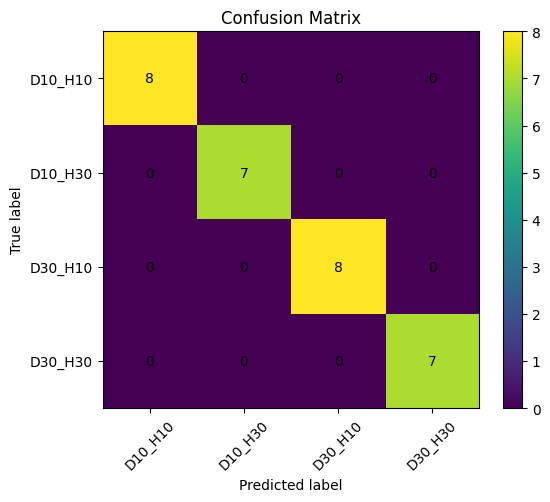

In [161]:
# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## Optional: predict one row from the CSV

This cell shows how to load the saved model and run prediction on one selected row from the CSV.


In [162]:
def preprocess_single_signal(signal_1d):
    signal_1d = np.asarray(signal_1d, dtype=np.float32)
    signal_1d = (signal_1d - signal_1d.mean()) / (signal_1d.std() + 1e-8)
    signal_1d = torch.tensor(signal_1d, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1, 1, L]
    return signal_1d

row_idx = 166  # change this
raw_df = pd.read_csv(CSV_PATH)

single_signal = raw_df.loc[row_idx, signal_cols].values.astype(np.float32)
single_input = preprocess_single_signal(single_signal).to(DEVICE)

best_model.eval()
with torch.no_grad():
    logits = best_model(single_input)
    pred_idx = int(torch.argmax(logits, dim=1).item())

print("Predicted class:", class_names[pred_idx])

if "label" in raw_df.columns:
    print("Actual class   :", raw_df.loc[row_idx, "label"])


Predicted class: D10_H30
Actual class   : D10_H30


## Notes

- Start with this 1D CNN as your baseline.
- If your dataset is still small, keep the model simple and avoid very deep networks.
- If accuracy is unstable, the first things to try are:
  - collect more rows per class
  - check label balance
  - reduce noise / bad captures
  - try a smaller crop around the most important part of the peak
  - add early stopping
